In [ ]:
from trainer import Trainer
import random
import matplotlib.pyplot as plt
import numpy as np
from optimizer import SGD
from batch_iterator import BatchIterator
from engine import Value
from nn import AutoEncoder
from loss_funcs import mean_squared_error
from utils import mnist_reader
random.seed(1337)
np.random.seed(1337)
np.set_printoptions(suppress=True)

In [ ]:
X_train, y_train = mnist_reader.load_mnist('data', kind='train')
X_test, y_test = mnist_reader.load_mnist('data', kind='t10k')

X_train = Value(X_train.astype(np.float32) / 255.0)
X_test  = Value(X_test.astype(np.float32) / 255.0)


X_train_img = X_train.data.reshape(-1, 28, 28)
X_test_img  = X_test.data.reshape(-1, 28, 28)


In [62]:
auto = AutoEncoder(in_embeds=784, hidden_layers=[
                   392, 196, 98], latent_dim=50, act_func=Value.sigmoid)
optimiser = SGD(auto.parameters(), learning_rate=1)
data_iterator = BatchIterator(X_train, X_train, 32)
trainer = Trainer(auto, optimiser, loss=mean_squared_error)


history = trainer.fit(data_iterator, num_epochs=20, verbose=True)


Epoch [1/20], loss: 0.072990, 
Epoch [2/20], loss: 0.040893, 
Epoch [3/20], loss: 0.035596, 
Epoch [4/20], loss: 0.030859, 
Epoch [5/20], loss: 0.028531, 
Epoch [6/20], loss: 0.026851, 
Epoch [7/20], loss: 0.025602, 
Epoch [8/20], loss: 0.024653, 
Epoch [9/20], loss: 0.023717, 
Epoch [10/20], loss: 0.022843, 
Epoch [11/20], loss: 0.022070, 
Epoch [12/20], loss: 0.021414, 
Epoch [13/20], loss: 0.020782, 
Epoch [14/20], loss: 0.020228, 
Epoch [15/20], loss: 0.019809, 
Epoch [16/20], loss: 0.019403, 
Epoch [17/20], loss: 0.019083, 
Epoch [18/20], loss: 0.018790, 
Epoch [19/20], loss: 0.018477, 
Epoch [20/20], loss: 0.018220, 


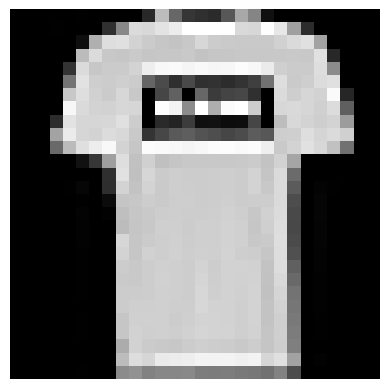

In [ ]:
def display_image_on_ax(X, ax):
    rearranged = np.reshape(X, (28, 28))
    ax.imshow(rearranged, cmap='gray')
    ax.axis('off')

fig, ax = plt.subplots(nrows=1, ncols=1) 

display_image_on_ax(X_train_img[1], ax)
plt.show()

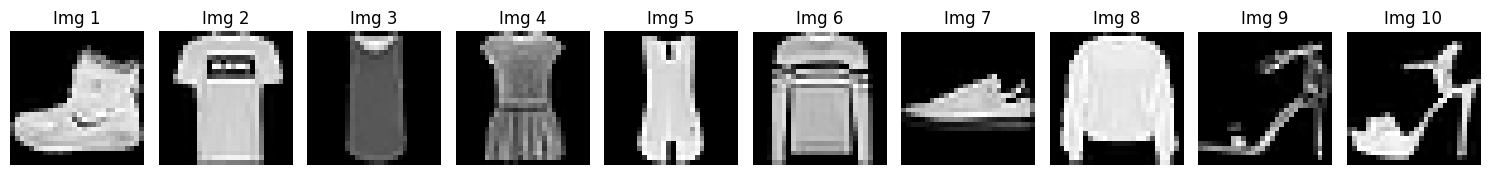

In [ ]:
num_images_to_display = 10


fig, axes = plt.subplots(nrows=1, ncols=num_images_to_display, figsize=(15, 2))

for k in range(num_images_to_display):
    display_image_on_ax(X_train_img[k], axes[k])
    
    axes[k].set_title(f"Img {k+1}")

plt.tight_layout()
plt.show()

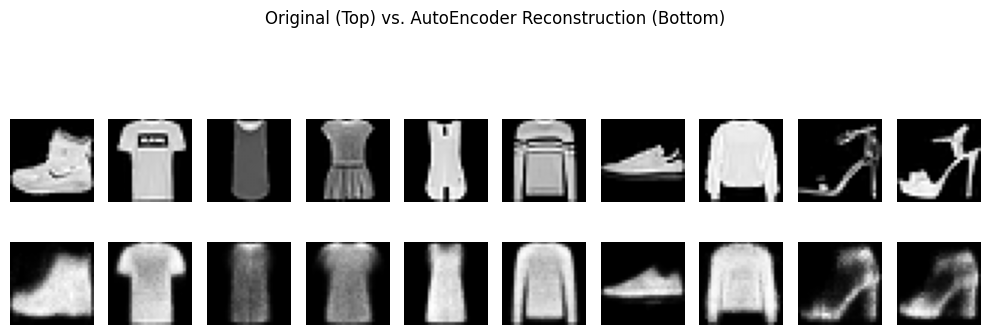

In [ ]:
num_samples_to_show = 10
fig, axes = plt.subplots(nrows=2, ncols=num_samples_to_show, figsize=(10, 4))
fig.suptitle("Original (Top) vs. AutoEncoder Reconstruction (Bottom)")

for j in range(num_samples_to_show):

    original_sample_value = X_train_img[j]
        
    display_image_on_ax(original_sample_value, axes[0, j])

    recon_val = auto(X_train[j])
    recon_val_img = recon_val.data.reshape(-1, 28, 28)
    
    display_image_on_ax(recon_val_img, axes[1, j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
from nn import VariationalAutoEncoder
from loss_funcs import vae_loss
import trainer
from importlib import reload 

reloaded_trainer = reload(trainer)

vae = VariationalAutoEncoder(in_embeds=784, hidden_layers=[
                   392, 196, 98], latent_dim=50, act_func=Value.sigmoid)
vae_optimiser = SGD(vae.parameters(), learning_rate=1)
vae_data_iterator = BatchIterator(X_train, X_train, 64)
vae_trainer = reloaded_trainer.Trainer(vae, vae_optimiser, loss=vae_loss)


vae_history = vae_trainer.vae_fit(vae_data_iterator, num_epochs=20, verbose=True)

Epoch [1/20], loss: 0.093341, 
Epoch [2/20], loss: 0.082422, 
Epoch [3/20], loss: 0.073478, 
Epoch [4/20], loss: 0.066081, 
Epoch [5/20], loss: 0.060466, 
Epoch [6/20], loss: 0.057808, 
Epoch [7/20], loss: 0.055203, 
Epoch [8/20], loss: 0.052815, 
Epoch [9/20], loss: 0.050631, 
Epoch [10/20], loss: 0.049075, 
Epoch [11/20], loss: 0.048325, 
Epoch [12/20], loss: 0.047628, 
Epoch [13/20], loss: 0.047150, 
Epoch [14/20], loss: 0.046720, 
Epoch [15/20], loss: 0.046264, 
Epoch [16/20], loss: 0.045928, 
Epoch [17/20], loss: 0.045554, 
Epoch [18/20], loss: 0.045221, 
Epoch [19/20], loss: 0.044833, 
Epoch [20/20], loss: 0.044493, 


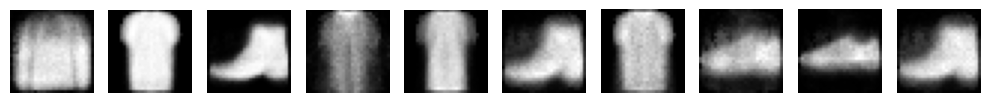

In [ ]:
test_vals = Value(np.random.normal(size=(10, vae.latent_dim)))

decoded = vae.decode(test_vals)

fig, axes = plt.subplots(nrows=1, ncols=len(test_vals.data), figsize=(10, 4))

for j in range(len(test_vals.data)):
    
    recon_val_img = decoded.data[j].reshape(-1, 28, 28)
    
    display_image_on_ax(recon_val_img, axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()